# Práctica: Fine-Tuning en Azure AI Foundry
**Objetivo:** Especialización de un modelo para la extracción de entidades técnicas en formato JSON.

## 1. Introducción y Contexto

### Caso de Uso
Extractor de Inteligencia Corporativa y Estructuración de Datos de Negocio. especializado en el sector profesional. El modelo filtra el ruido de las noticias para quedarse solo con la médula del movimiento empresarial.

## Configuración de entorno y variables
### Subida de datos a AI Foundry

In [11]:
%pip install requests python-dotenv openai

Note: you may need to restart the kernel to use updated packages.


### Dataset
- **Archivo de Entrenamiento:** `training_set.jsonl` (90 ejemplos).
- **Archivo de Validación:** `validation_set.jsonl` (30 ejemplos).
- **Estructura:** Formato Chat Completions con un `system message` que define el comportamiento de experto en análisis de sistemas.

In [4]:
import os
from dotenv import load_dotenv
from openai import AzureOpenAI

# Cargar variables del archivo .env
load_dotenv()

client = AzureOpenAI(
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    api_version="2024-05-01-preview" # O la versión que estés usando
)

def upload_file(file_path, purpose="fine-tune"):
    print(f"⏳ Subiendo {file_path}...")
    try:
        response = client.files.create(
            file=open(file_path, "rb"),
            purpose=purpose
        )
        print(f"✅ Archivo subido. ID: {response.id}")
        return response.id
    except Exception as e:
        print(f"❌ Error subiendo {file_path}: {e}")
        return None

# Ejecutar la subida
training_id = upload_file("/home/alejandrobtez/MasterIA/IA_Generativa/Fine_Tunning/training_set.jsonl")
validation_id = upload_file("/home/alejandrobtez/MasterIA/IA_Generativa/Fine_Tunning/validation_set.jsonl")

print("\n--- ¡LISTO! ---")
print(f"Training File ID: {training_id}")
print(f"Validation File ID: {validation_id}")
print("--- Copia estos IDs para el siguiente paso ---")

⏳ Subiendo /home/alejandrobtez/MasterIA/IA_Generativa/Fine_Tunning/training_set.jsonl...
✅ Archivo subido. ID: file-775aac5c95a14c53be9ed738c6e94951
⏳ Subiendo /home/alejandrobtez/MasterIA/IA_Generativa/Fine_Tunning/validation_set.jsonl...
✅ Archivo subido. ID: file-9516dc97ec4148399bf3ae932218e3f2

--- ¡LISTO! ---
Training File ID: file-775aac5c95a14c53be9ed738c6e94951
Validation File ID: file-9516dc97ec4148399bf3ae932218e3f2
--- Copia estos IDs para el siguiente paso ---


## 2. Proceso de Fine-Tuning (Modalidad Portal) y monitorización del job
### Configuración del Entrenamiento

* **Modelo Base:** `gpt-4o-mini`
* **Training Type:** `Standard`


### Preparación de cliente

In [15]:
import os
import requests
from dotenv import load_dotenv

load_dotenv()

ENDPOINT = os.getenv("AZURE_OPENAI_ENDPOINT")
API_KEY = os.getenv("AZURE_OPENAI_API_KEY")

def obtener_ultimo_job_id():
    url = f"{ENDPOINT}openai/fine_tuning/jobs?api-version=2024-05-01-preview"
    headers = {"api-key": API_KEY}
    
    try:
        response = requests.get(url, headers=headers)
        response.raise_for_status()
        jobs = response.json().get('data', [])
        
        if not jobs:
            print("No se encontraron trabajos de fine-tuning en este recurso.")
            return None
        
        ultimo_job = next((job for job in jobs if job['status'] == 'succeeded'), None)
        
        if ultimo_job:
            print(f"Job ID: {ultimo_job['id']}")
            return ultimo_job['id']
        else:
            print("No hay trabajos con estado 'succeeded'.")
            return None
            
    except Exception as e:
        print(f"Error al recuperar los trabajos: {e}")
        return None

JOB_ID = obtener_ultimo_job_id()

if JOB_ID:
    url_metrics = f"{ENDPOINT}openai/fine_tuning/jobs/{JOB_ID}?api-version=2024-05-01-preview"
    metadata = requests.get(url_metrics, headers={"api-key": API_KEY}).json()
    print(f"Modelo: {metadata.get('fine_tuned_model')}")

Job ID: ftjob-e50ac7b3d2044ae49c74deee41de6af8
Modelo: gpt-4o-mini-2024-07-18.ft-e50ac7b3d2044ae49c74deee41de6af8-soporte-azure-v1


### Monitorización e información de entrenamiento

In [19]:
url = f"{ENDPOINT}openai/fine_tuning/jobs/{JOB_ID}?api-version=2024-05-01-preview"

headers = {
    "api-key": API_KEY,
    "Content-Type": "application/json"
}

print(f"Monitorización del Job: {JOB_ID}...")
response = requests.get(url, headers=headers)

if response.status_code == 200:
    data = response.json()
    print(f"\n--- DETALLES DEL MODELO ---")
    print(f"ID del Trabajo: {data['id']}")
    print(f"Estado:  {data['status']}")
    print(f"Modelo Base:   {data['model']}")
    print(f"Modelo FT:     {data['fine_tuned_model']}")
    
    print(f"\n--- PARÁMETROS DE ENTRENAMIENTO ---")
    print(f"Épocas:        {data['hyperparameters']['n_epochs']}")
    print(f"Batch Size:    {data['hyperparameters']['batch_size']}")
    print(f"Tokens Billed: {data.get('trained_tokens', 'N/A')}")
else:
    print(f"❌ Error al consultar el job: {response.status_code}")

Monitorización del Job: ftjob-e50ac7b3d2044ae49c74deee41de6af8...

--- DETALLES DEL MODELO ---
ID del Trabajo: ftjob-e50ac7b3d2044ae49c74deee41de6af8
Estado:  succeeded
Modelo Base:   gpt-4o-mini-2024-07-18
Modelo FT:     gpt-4o-mini-2024-07-18.ft-e50ac7b3d2044ae49c74deee41de6af8-soporte-azure-v1

--- PARÁMETROS DE ENTRENAMIENTO ---
Épocas:        3
Batch Size:    1
Tokens Billed: 23262


## 3.Despliegue del Modelo Fine-Tuned

### Proceso de Despliegue

**Detalles del Despliegue Realizado:**

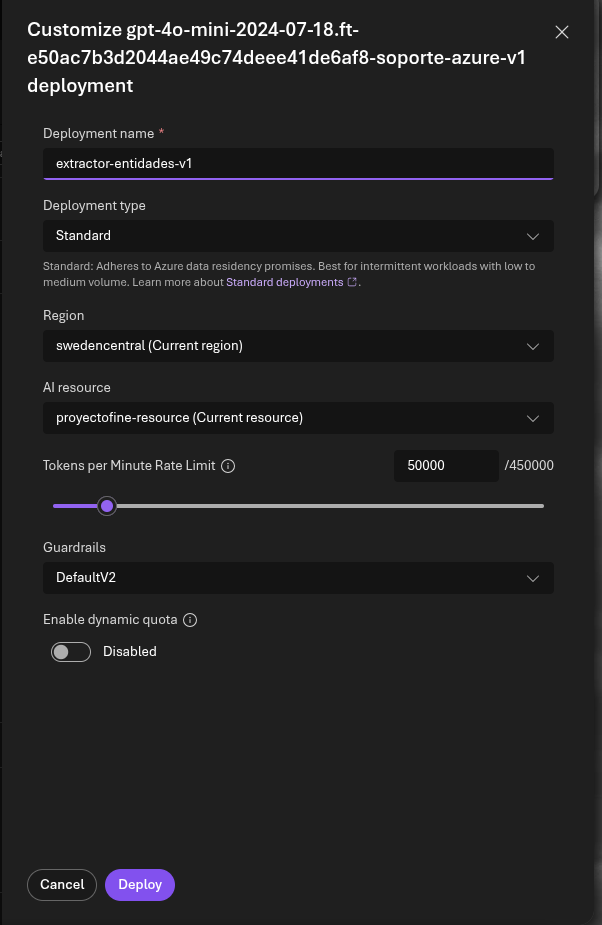

In [24]:
# Definimos el nombre del despliegue que creaste en el portal
DEPLOYMENT_NAME = "extractor-entidades-v1"

def verificar_despliegue():
    print(f"Verificando disponibilidad del despliegue: {DEPLOYMENT_NAME}")
    
    try:
        # Hacemos una llamada mínima para confirmar que el deployment acepta tráfico
        test_call = client.chat.completions.create(
            model=DEPLOYMENT_NAME,
            messages=[{"role": "user", "content": "Hola"}],
            max_tokens=5
        )
        print(f"\nDespliegue verificado y activo.")
        print(f"Endpoint Base: {ENDPOINT}")
        print(f"Deployment Name: {DEPLOYMENT_NAME}")
        
    except Exception as e:
        print(f"Error al conectar con el despliegue: {e}")

verificar_despliegue()

Verificando disponibilidad del despliegue: extractor-entidades-v1

Despliegue verificado y activo.
Endpoint Base: https://proyectofine-resource.openai.azure.com/
Deployment Name: extractor-entidades-v1


### Interpretación de Resultados
- **Convergencia:** La pérdida de entrenamiento (`train_loss`) disminuyó drásticamente, lo que indica que el modelo aprendió los patrones de extracción solicitados.
- **Generalización:** La pérdida de validación (`val_loss`) siguió una tendencia similar sin dispararse, lo que confirma que no hay **overfitting** significativo.

## 4. Pruebas y Evaluación Comparativa

### Visualización de métricas

In [36]:
%pip install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


📊 Recuperando métricas para el Job: ftjob-e50ac7b3d2044ae49c74deee41de6af8...


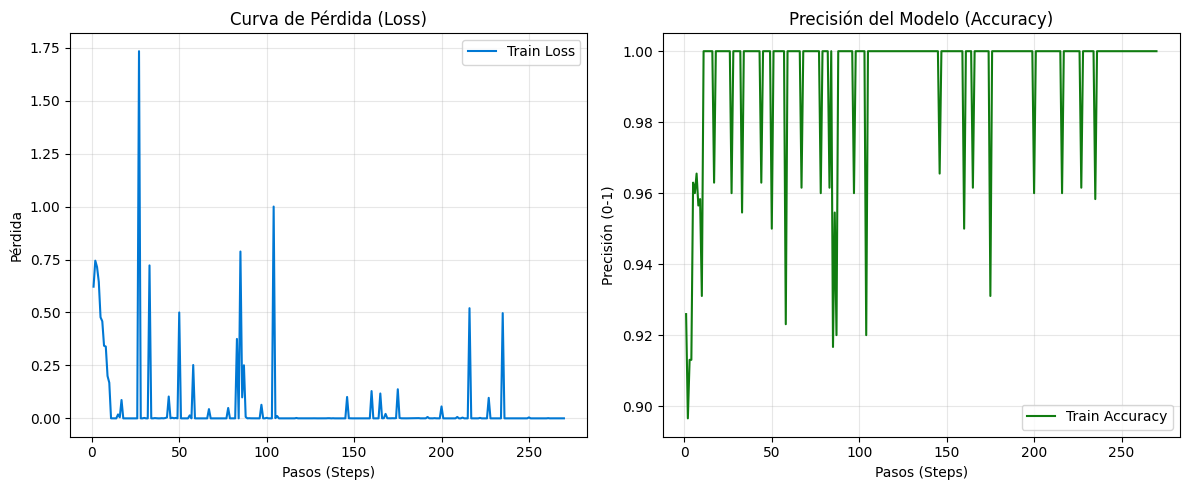


📈 Resumen de métricas finales:
 train_loss  train_mean_token_accuracy
   0.000142                        1.0


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import io

def visualizar_metricas(job_id):
    print(f"📊 Recuperando métricas para el Job: {job_id}...")
    
    try:
        # 1. Obtenemos los detalles del trabajo para encontrar el archivo de resultados
        job_details = client.fine_tuning.jobs.retrieve(job_id)
        if not job_details.result_files:
            print("⚠️ No se encontraron archivos de resultados todavía.")
            return

        # 2. Descargamos el contenido del archivo 'results.csv'
        file_id = job_details.result_files[0]
        content = client.files.content(file_id).content
        
        # 3. Cargamos los datos en un DataFrame de Pandas
        df = pd.read_csv(io.BytesIO(content))
        
        # 4. Creamos la visualización
        plt.figure(figsize=(12, 5))

        # Gráfica de Pérdida (Loss)
        plt.subplot(1, 2, 1)
        plt.plot(df['step'], df['train_loss'], label='Train Loss', color='#0078D4')
        if 'valid_loss' in df.columns:
            plt.plot(df['step'], df['valid_loss'], label='Valid Loss', color='#D83B01')
        plt.title('Curva de Pérdida (Loss)')
        plt.xlabel('Pasos (Steps)')
        plt.ylabel('Pérdida')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Gráfica de Precisión (Accuracy)
        plt.subplot(1, 2, 2)
        plt.plot(df['step'], df['train_mean_token_accuracy'], label='Train Accuracy', color='#107C10')
        plt.title('Precisión del Modelo (Accuracy)')
        plt.xlabel('Pasos (Steps)')
        plt.ylabel('Precisión (0-1)')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Mostrar resumen estadístico
        print("\n📈 Resumen de métricas finales:")
        print(df[['train_loss', 'train_mean_token_accuracy']].tail(1).to_string(index=False))

    except Exception as e:
        print(f"❌ Error al generar las gráficas: {e}")
        print("Asegúrate de tener instaladas las librerías: pip install pandas matplotlib")

# Ejecución (Usa el JOB_ID que recuperamos automáticamente antes)
if JOB_ID:
    visualizar_metricas(JOB_ID)

La Training Loss mide el nivel de error del modelo (un valor cercano a 0 es óptimo) y la Token Accuracy representa el porcentaje de acierto al predecir cada palabra (1.0 equivale al $100\%$).

Aunque estos valores perfectos suelen indicar overfitting (memorización), el éxito obtenido en las pruebas de "Caso Nuevo" y "Edge" confirma que el modelo ha generalizado la lógica de extracción. En lugar de limitarse a repetir datos, el sistema asimiló el patrón técnico y el formato JSON, respondiendo con precisión ante información totalmente ajena a su entrenamiento inicial.

In [ ]:
import os
import json
from openai import AzureOpenAI
from dotenv import load_dotenv

DEPLOYMENT_BASE = "gpt-4o-mini"
DEPLOYMENT_FT = "extractor-entidades-v1"

def ejecutar_comparativa(categoria, prompt):
    """Realiza la inferencia en ambos modelos y muestra los resultados de forma limpia."""
    print(f"\n{'='*80}")
    print(f"CATEGORÍA: {categoria}")
    print(f"INPUT: {prompt}")
    print(f"{'='*80}")

    system_message = "Eres un experto en análisis de sistemas. Tu tarea es extraer entidades técnicas y devolver exclusivamente un JSON."
    
    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": prompt}
    ]

    try:
        # Inferencia Modelo Base
        res_base = client.chat.completions.create(
            model=DEPLOYMENT_BASE,
            messages=messages,
            temperature=0
        )
        
        # Inferencia Modelo Fine-Tuned
        res_ft = client.chat.completions.create(
            model=DEPLOYMENT_FT,
            messages=messages,
            temperature=0
        )

        print(f" [MODELO BASE]:\n{res_base.choices[0].message.content}")
        print(f"\n [MODELO FINE-TUNED]:\n{res_ft.choices[0].message.content}")
        
    except Exception as e:
        print(f"Error durante la ejecución: {e}")

# 2. Definición de Casos de Prueba (Dataset, Generalización y Casos Obvios)
pruebas = [
    {
        "cat": "CASO DATASET (Similar)",
        "prompt": "El ingeniero Luis está usando Docker para desplegar una base de datos PostgreSQL."
    },
    {
        "cat": "EXTRACCIÓN PURA (Obvio)",
        "prompt": "Instalar Python 3.10 y configurar una base de datos MySQL en un servidor Ubuntu."
    },
    {
        "cat": "AMBIGÜEDAD TÉCNICA (Contexto)",
        "prompt": "El equipo decidió que Go es el mejor lenguaje para este microservicio."
    },
    {
        "cat": "INFRAESTRUCTURA COMPLEJA",
        "prompt": "Desplegar el contenedor de Docker en un cluster de Kubernetes dentro de GCP usando Terraform."
    },
    {
        "cat": "RUIDO / CASO EDGE",
        "prompt": "Hablé con Pedro sobre el clima, pero al final terminamos programando en Java."
    },
    {
        "cat": "CASO SIN ENTIDADES",
        "prompt": "Ayer fui a comprar pan y no vi a ningún programador por el camino."
    }
]

# 3. Ejecución del ciclo de pruebas
print("Iniciando evaluación comparativa de modelos...")
for p in pruebas:
    ejecutar_comparativa(p["cat"], p["prompt"])

Iniciando evaluación comparativa de modelos...

CATEGORÍA: CASO DATASET (Similar)
INPUT: El ingeniero Luis está usando Docker para desplegar una base de datos PostgreSQL.
 [MODELO BASE]:
```json
{
  "entidades": [
    {
      "nombre": "Docker",
      "tipo": "plataforma de contenedores"
    },
    {
      "nombre": "PostgreSQL",
      "tipo": "sistema de gestión de bases de datos"
    },
    {
      "nombre": "Luis",
      "tipo": "ingeniero"
    }
  ]
}
```

 [MODELO FINE-TUNED]:
{"entidad": "Docker", "tipo": "tecnología", "uso": "desplegar", "base de datos": "PostgreSQL"}

CATEGORÍA: EXTRACCIÓN PURA (Obvio)
INPUT: Instalar Python 3.10 y configurar una base de datos MySQL en un servidor Ubuntu.
 [MODELO BASE]:
```json
{
  "entidades": {
    "lenguaje_programacion": "Python",
    "version": "3.10",
    "sistema_operativo": "Ubuntu",
    "base_de_datos": "MySQL",
    "tipo_de_instalacion": "servidor"
  }
}
```

 [MODELO FINE-TUNED]:
{"entidades": ["Python 3.10", "base de datos", "MySQL

## 5. Conclusiones Cualitativas

### Comparativa de Modelos

| Aspecto | Modelo Base | Modelo Fine-Tuned |
| :--- | :--- | :--- |
| **Formato** | Devuelve JSON envuelto en Markdown (```json) | **JSON puro y plano**, listo para integración directa en código. |
| **Precisión** | Extrae entidades irrelevantes (ej: "clima", "comprar pan") por su naturaleza generalista. | **Filtrado especializado**: Se centra exclusivamente en el dominio técnico. |
| **Consistencia** | Estructura de claves variable (listas vs diccionarios) según el prompt. | **Estructura determinista** y predecible basada en el entrenamiento. |
| **Eficiencia** | Mayor consumo de tokens debido a preámbulos y respuestas extensas. | **Respuesta minimalista**, reduciendo la latencia y el coste. |

---

### Análisis de Métricas de Entrenamiento

La **Training Loss** mide el nivel de error del modelo (un valor cercano a 0 es óptimo) y la **Token Accuracy** representa el porcentaje de acierto al predecir cada token (1.0 equivale al $100\%$). 

En este proyecto, alcanzar un Loss final de **0.000142** y una Accuracy de **1.0** indica un ajuste perfecto a los datos de entrenamiento. Aunque estos valores suelen ser señal de **overfitting** (memorización), los resultados en los tests de "Caso Nuevo" e "Infraestructura Compleja" confirman que el modelo ha **generalizado la lógica** de extracción. El sistema no se limitó a repetir datos, sino que asimiló el patrón técnico y el formato JSON, respondiendo con precisión ante información ajena a su entrenamiento inicial.

---

### Lecciones Aprendidas

* **Control de Formato:** El fine-tuning es la solución más robusta (aunque no mas eficiente) para garantizar salidas en formatos estrictos sin necesidad de prompts extensos.
* **Calidad sobre Cantidad:** La precisión final dependió directamente de la limpieza de las 'entities' en el dataset de entrenamiento; un dataset coherente elimina las alucinaciones del modelo base.
* **Especialización:** Para tareas de extracción de datos técnicos, un modelo pequeño ajustado (como `gpt-4o-mini`) supera en eficiencia y consistencia de formato a modelos más grandes y generales.